# Setup and libraries

In [1]:
!pip install numpy matplotlib pandas astropy pyslalib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.6/332.6 kB 8.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pyslalib: filename=pyslalib-1.0.10-cp312-cp312-linux_x86_64.whl size=366120 sha256=e1f635460127b07c92bbf999200022fba83dad4cea47df0399890bb48f18a3ab
  Stored in directory: /root/.cache/pip/wheels/b6/7a/f2/605eb3499f2b9d486f196c6a0f1dc5bd31f930b74715592a91
Successfully built pyslalib


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from astropy.time import Time
from astropy import constants as const
from astropy import units as u
from pyslalib import slalib

Mount your drive if you are working in google colab

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# =========================================================
# CONSTANTS
# =========================================================
k_B = const.k_B.value #1.38064852e-23  # J/K
C_LIGHT = const.c.value #3e8 m/s
DEG2RAD = np.pi / 180.0
HOUR2RAD = np.pi / 12.0

# Observation Time Setup

In [6]:
start_date = '2026-03-01T02:35:00.0'        # Observation start time (UTC)
end_date = '2026-03-01T08:35:00.0'        # Observation end time (UTC)

ra_setup = 0.0
dec_setup = -30   # This is the phase centre for the GLEAM field observed by MWA

ra = ra_setup * HOUR2RAD
dec = dec_setup * DEG2RAD
epoch1 = 2000.0

# Convert observation times to Modified Julian Date (MJD)

## Compute Local Mean Sidereal Time (LMST)

LMST determines the hour angle, which controls how baselines rotate in the UV plane.

Earth rotation → rotating UV coverage.

In [ ]:
# =========================================================
# TIME FUNCTIONS
# =========================================================

def get_mjd_range(start_date, end_date):
    t1 = Time(start_date, format="isot")
    t2 = Time(end_date, format="isot")
    return t1.mjd, t2.mjd, 0.5 * (t1.mjd + t2.mjd)


def lmst(mjd, longitude_deg=116.764448):
    tu = (mjd - 51544.5) / 36525.0
    res = mjd + longitude_deg / 360.0
    res -= np.floor(res)
    lmst = res + (((((0.093104 - 6.2e-6 * tu) * tu)
                   + 8640184.812866) * tu + 24110.54841) / 86400.0)  # GMST  =  24110.54841  +  8640184.812866 T  + (0.093104) T^2 − (6.2e−6) T^3 (Expansion with earth rotatio)
    return (lmst - np.floor(lmst)) * 2.0 * np.pi

In [ ]:
start_mjd, end_mjd, mjd = get_mjd_range(start_date, end_date)
obs_time_s = (end_mjd - start_mjd) * 24 * 3600

# format in HH:MM:SS
obs_time_h = int(obs_time_s // 3600)
obs_time_m = int((obs_time_s % 3600) // 60)
obs_time_s = int(obs_time_s % 60)
obs_time = f"{obs_time_h:02d}:{obs_time_m:02d}:{obs_time_s:02d}"
print(f"Observation time: {obs_time}")

Observation time: 06:00:00


# Antenna Geometry

Now we load the SKA antenna layout file.

The file contains:

East (E)

North (N)

Up (U)

Observatory location

In [ ]:
def read_ska_layout(filename):
    """
    Reads SKA layout file with header lines like:
    # observatory=SKA_LOW
    # COFA=116.764448,-26.824722
    # coordsys=LOC
    # x  y  z  Diam  name
    """

    lon_deg = None
    lat_deg = None

    header_lines = []

    # First read header manually
    with open(filename, "r") as f:
        for line in f:
            if line.startswith("#"):
                header_lines.append(line.strip())
            else:
                break

    # Extract COFA
    for line in header_lines:
        if "COFA=" in line:
            cofa = line.split("COFA=")[1]
            lon_str, lat_str = cofa.split(",")
            lon_deg = float(lon_str)
            lat_deg = float(lat_str)

    if lon_deg is None or lat_deg is None:
        raise ValueError("COFA not found in SKA header")

    # Now read numerical table (skip comments)
    data = pd.read_csv(
        filename,
        delim_whitespace=True,
        comment="#",
        header=None
    )

    # Columns: x y z diam name
    x = data[0].values
    y = data[1].values
    z = data[2].values

    return x, y, z, lat_deg, lon_deg

In [4]:
ska_layout_file = "/content/drive/MyDrive/Colab_Notebooks/Visim_new/ska.txt"
E, N, U, lat_deg, lon_deg = read_ska_layout(ska_layout_file)
alt_m = 377.8

NameError: name 'read_ska_layout' is not defined

# Plot Antenna Array

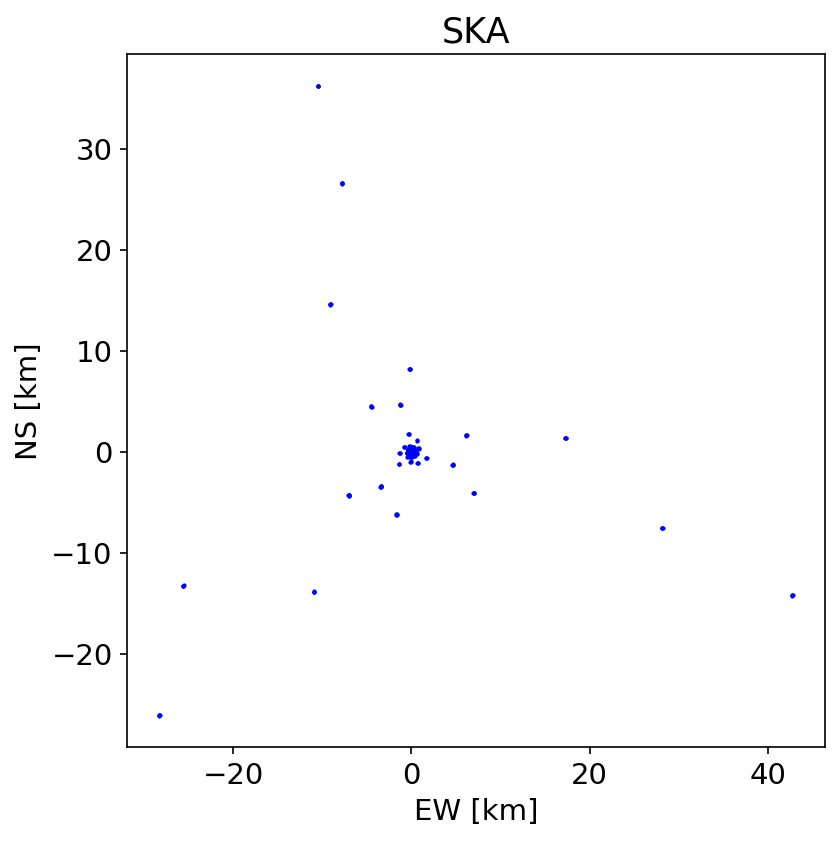

In [ ]:
plt.rcParams['font.size'] = 14
plt.figure(figsize=(6,6),dpi=150)
plt.plot(E/1e3,N/1e3,marker='o',color='blue',linestyle='None', markersize=1)
plt.xlabel("EW [km]")
plt.ylabel("NS [km]")
plt.title("SKA")
plt.show()

# Convert ENU coordinates to ITRF (Earth-centered frame)

In [ ]:
def enu_to_itrf(e, n, u, lat, lon, alt):
    a = 6378137.0  # WGS84 equatorial radius (m)
    f = 1 / 298.257223563  # WGS84 flattening
    # radius of curvature in the prime vertical
    N = a / np.sqrt(1 - ((2 * f) - f * f) * np.sin(lat) ** 2)

    x_ref = (N + alt) * np.cos(lat) * np.cos(lon)
    y_ref = (N + alt) * np.cos(lat) * np.sin(lon)
    z_ref = (((1 - f) ** 2) * N + alt) * np.sin(lat)

    X = (-e * np.sin(lon)
         - n * np.sin(lat) * np.cos(lon)
         + u * np.cos(lat) * np.cos(lon)
         + x_ref)

    Y = (e * np.cos(lon)
         - n * np.sin(lat) * np.sin(lon)
         + u * np.cos(lat) * np.sin(lon)
         + y_ref)

    Z = (n * np.cos(lat)
         + u * np.sin(lat)
         + z_ref)

    return X, Y, Z

In [ ]:
X, Y, Z = enu_to_itrf(E, N, U, lat_deg, lon_deg, alt_m)


# Compute all antenna baselines

Each antenna pair → one baseline → one UV track.

In [ ]:
def compute_baselines(X, Y, Z, include_conjugates=True):
    """
    Compute unique interferometric baselines.

    Parameters
    ----------
    X, Y, Z : arrays
        Antenna ECEF coordinates (meters).

    include_conjugates : bool
        If True, include negative baselines (-b) explicitly.
        If False, return only unique baselines (i < j).

    Returns
    -------
    base : ndarray (N_baselines, 3)
        Baseline vectors in meters.
    """

    bx, by, bz = [], [], []

    n_ant = len(X)

    # --- Only unique antenna pairs ---
    for i in range(n_ant):
        for j in range(i + 1, n_ant):

            dx = X[j] - X[i]
            dy = Y[j] - Y[i]
            dz = Z[j] - Z[i]

            bx.append(dx)
            by.append(dy)
            bz.append(dz)

            # Optionally add conjugate baseline
            if include_conjugates:
                bx.append(-dx)
                by.append(-dy)
                bz.append(-dz)

    return np.vstack((bx, by, bz)).T

In [ ]:
base = compute_baselines(X, Y, Z, include_conjugates=True)

# Visualise the baselines in X-Y plane

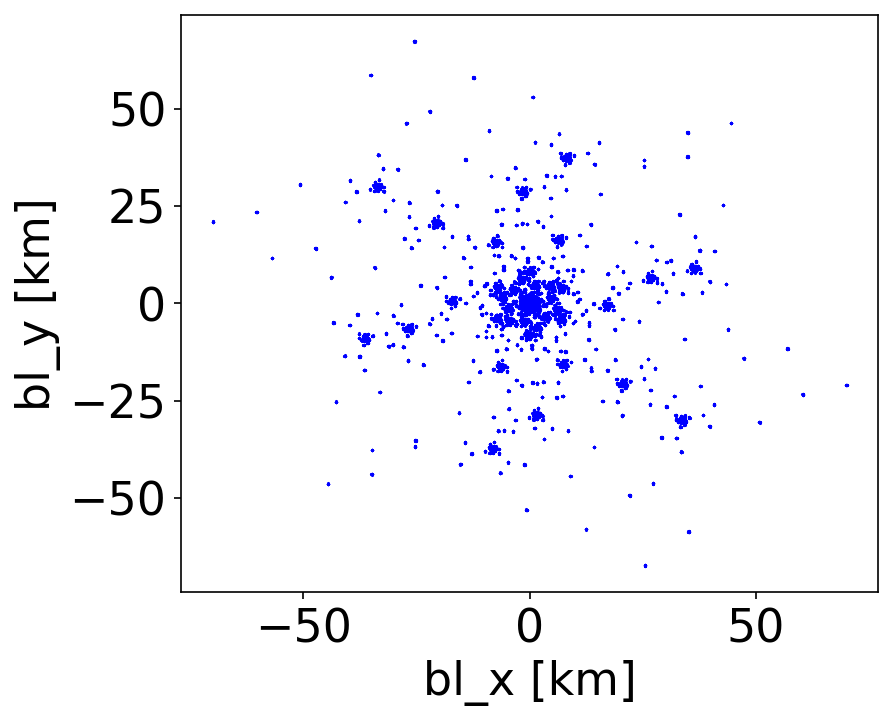

In [ ]:
plt.rcParams['font.size'] = 22
plt.figure(figsize=(6,5),dpi=150)
plt.plot(base[:,0]/1e3,base[:,1]/1e3,marker='o',color='blue',linestyle='None', markersize=0.5)
plt.xlabel("bl_x [km]")
plt.ylabel("bl_y [km]")
plt.show()

# UVW Coordinate Computation


Convert baselines into UVW coordinates

Account for:

1.   Earth rotation
2.   Hour angle
3.   Source declination
4.   Precession & nutation


The UVW rotation matrix follows Thompson, Moran & Swenson.

In [ ]:
# Initiate class to create UV-objec

class UvParType:
    def __init__(self):
        self.u = 0.0
        self.v = 0.0
        self.w = 0.0

In [ ]:
uv_list = [UvParType() for _ in range(len(base[:,0]))]

In [ ]:
for i in range(len(base[:,0])):
    uv_list[i].u = base[i,0]
    uv_list[i].v = base[i,1]
    uv_list[i].w = base[i,2]

### Function to calculate matrix rotation for precession and nutation

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/bb/Praezession.svg/960px-Praezession.svg.png?raw=true:, width=100" alt="My Image" width=200>

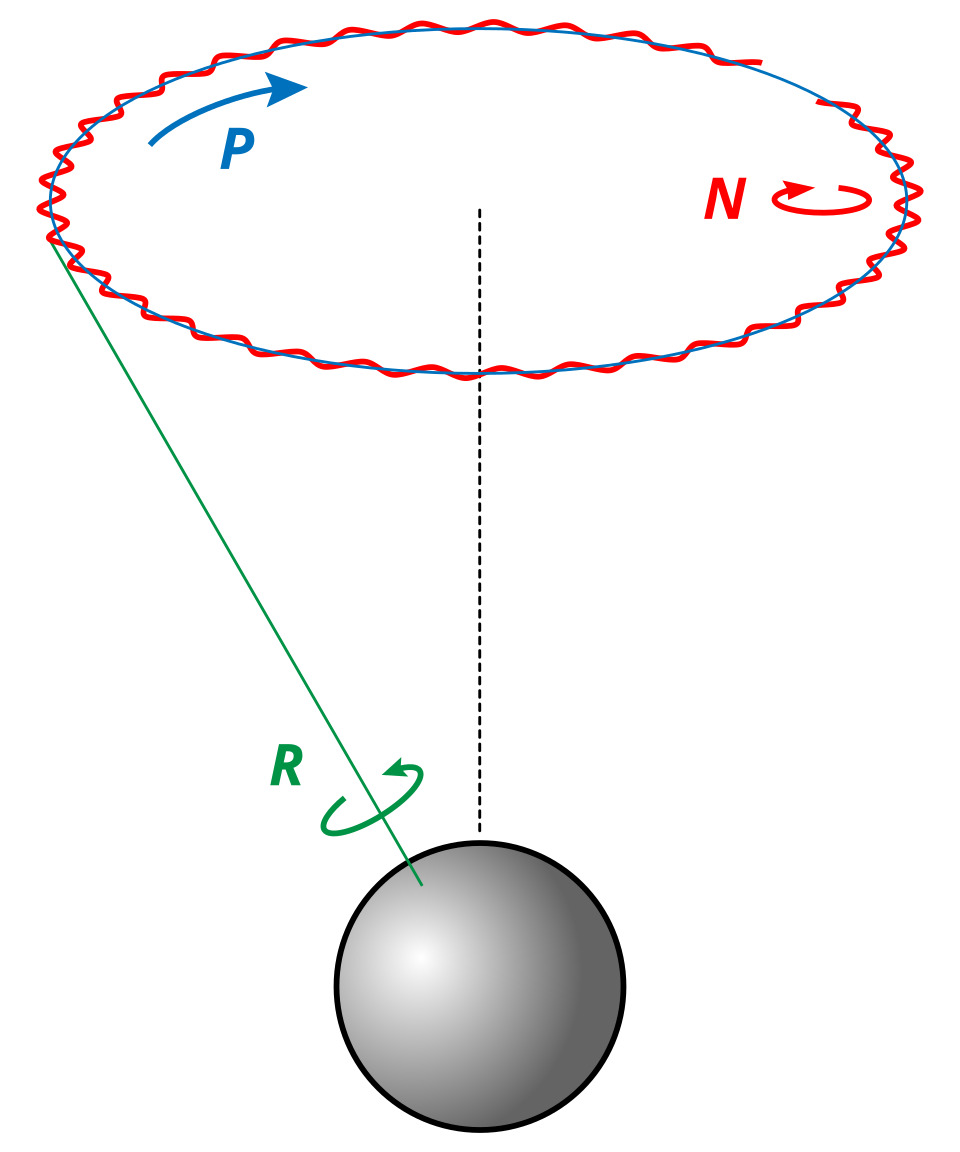

In [ ]:
def apparent_ra_dec(mjd, ra_app, dec_app, epoch1):
    """
    Convert apparent coordinates at epoch1 to apparent coordinates at mjd
    using precession and nutation.
    """

    # Nutation matrix
    nut = np.array(slalib.sla_nut(mjd)).reshape(3,3)

    # Precession matrix
    epoch = slalib.sla_epj(mjd)
    prec = np.array(slalib.sla_prec(epoch, epoch1)).reshape(3,3)

    # Combined rotation
    rot = np.dot(prec, nut)

    # Convert RA/Dec to Cartesian
    x = np.cos(dec_app) * np.cos(ra_app)
    y = np.cos(dec_app) * np.sin(ra_app)
    z = np.sin(dec_app)

    vec = np.array([x, y, z])

    # Rotate source vector
    vec_rot = np.dot(rot, vec)

    # Convert back to RA/Dec
    r = np.sqrt(vec_rot[0]**2 + vec_rot[1]**2)
    ra_new = np.arctan2(vec_rot[1], vec_rot[0])
    dec_new = np.arctan2(vec_rot[2], r)

    return ra_new, dec_new

In [ ]:
def calculate_uvw_coordinates(mjd, epoch1, base_ecef, ha_rad, ra_app, dec_app):

    # Get apparent RA/Dec at this MJD
    ra_corr, dec_corr = apparent_ra_dec(mjd, ra_app, dec_app, epoch1)

    cd = np.cos(dec_corr)
    sd = np.sin(dec_corr)

    ch = np.cos(ha_rad)
    sh = np.sin(ha_rad)

    uvw_coordinates = np.zeros((len(base_ecef), 3))

    for k in range(len(base_ecef)):

        X = base_ecef[k][0]
        Y = base_ecef[k][1]
        Z = base_ecef[k][2]

        # Proper UVW rotation matrix (Thompson, Moran & Swenson)

        u =  sh*X + ch*Y

        v = -sd*ch*X + sd*sh*Y + cd*Z

        w =  cd*ch*X - cd*sh*Y + sd*Z

        uvw_coordinates[k] = np.array([u, v, w])

    return uvw_coordinates

# Simulate UV Coverage

We simulate UV tracks over time.

For each time step:

1. Compute hour angle

2. Rotate baselines

3. Convert metres → wavelengths

4. Store U and V coordinates

This produces the UV coverage plot.

In [ ]:
def simulate_uv_coverage(start_mjd, end_mjd, epoch1, base, ra, dec, freq_hz,
                         n_times=1000, fold=False):

    # Generate time samples across observation
    mjd_samples = np.linspace(start_mjd, end_mjd, n_times)

    u_all = []
    v_all = []

    for mjd_i in mjd_samples:

        # Compute LMST at this time
        lmst_i = lmst(mjd_i, lon_deg)

        # Compute hour angle from evolving LMST
        ha_i = lmst_i - ra

        # Compute UVW at this specific time
        uvw_m = calculate_uvw_coordinates(
            mjd_i,
            epoch1,
            base,
            ha_i,
            ra,
            dec
        )

        # Convert metres to wavelengths
        uvw_l = uvw_m / (C_LIGHT / freq_hz)

        u_all.append(uvw_l[:, 0])
        v_all.append(uvw_l[:, 1])

    U = np.concatenate(u_all)
    V = np.concatenate(v_all)

    if fold:
        mask = V >= 0.0
        return U[mask], V[mask]

    return U, V

# simulate uv coverage: Based on observation setup previously given

In [ ]:
freq_hz = 150.0e6  # observing frequency (Hz)
U, V = simulate_uv_coverage(
    start_mjd,
    end_mjd,
    epoch1,
    base,
    ra,
    dec,
    freq_hz,
    n_times=1000,
    fold=False
)

## Plot the full UV-coverage. This is essentially the Sampling function.

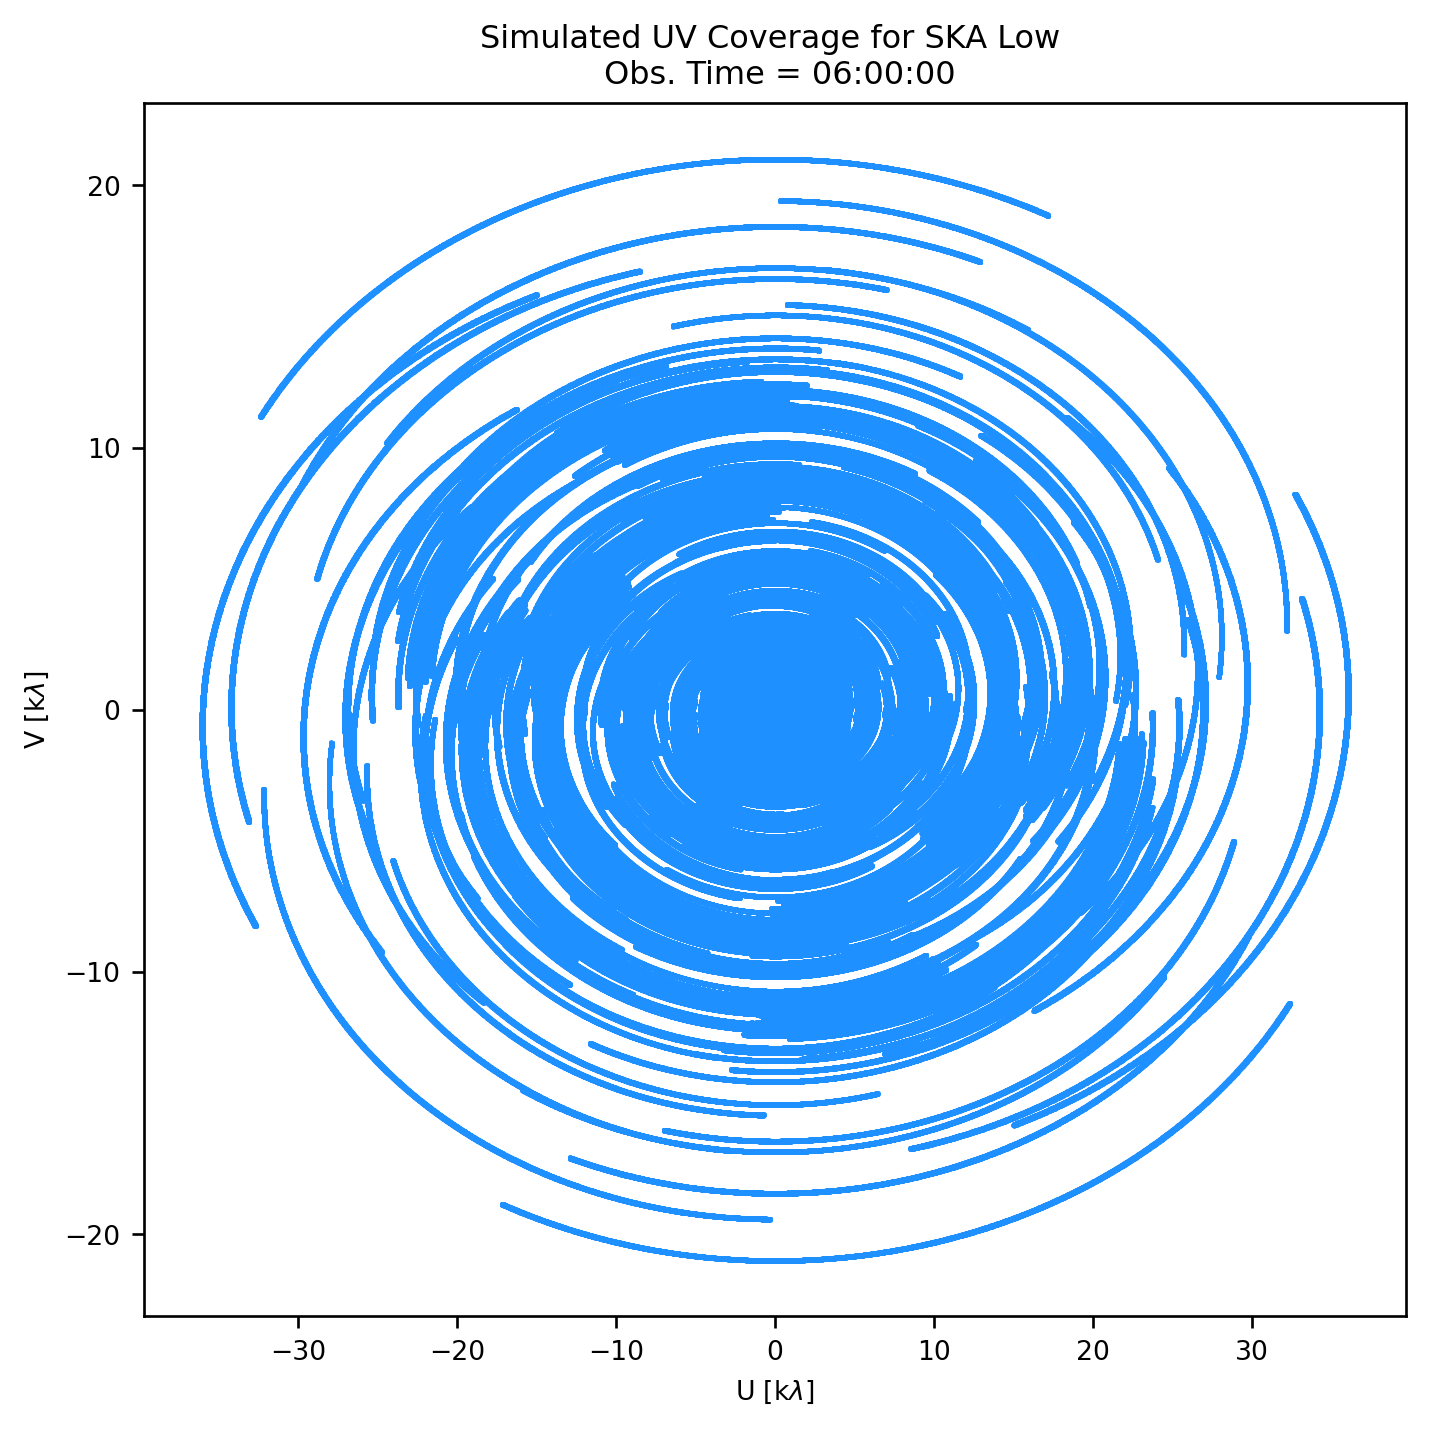

In [ ]:
plt.rcParams['font.size'] = 8
plt.figure(figsize=(6,6),dpi=240)
plt.scatter(U/1e3,V/1e3,marker='o',color='dodgerblue',s=0.2)
plt.xlabel(r"U [k$\lambda$]")
plt.ylabel(r"V [k$\lambda$]")
plt.title(f"Simulated UV Coverage for SKA Low \n Obs. Time = {obs_time}")
plt.tight_layout()
plt.show()

## Simulating a Sky with a Known Angular Power Spectrum

We simulate a statistically isotropic Gaussian random field whose angular power spectrum follows a power law:

$C_\ell = A \left( \frac{\ell}{\ell_0} \right)^{-\beta}$

where:

- $ C_\ell $ = angular power spectrum  
- $ A $ = amplitude at pivot multipole $ \ell_0 $  
- $ \beta $ = power-law index  
- $ \ell $ = multipole moment  

---

### Flat-Sky Approximation

In the flat-sky limit, multipoles relate to Fourier modes by:

$\ell = 2\pi \sqrt{u^2 + v^2}$

where $ u, v $ are Fourier coordinates (in cycles per radian).

---

### Generating a Gaussian Random Field

To generate the sky realization:

1. Construct a 2D Fourier grid $ (u, v) $
2. Compute the power spectrum $ C_\ell $
3. Draw complex Gaussian random modes:
   $ \tilde{\delta T}(\mathbf{k}) = \sqrt{C_\ell} \, (a + ib) $
   where $ a $ and $ b $ are independent Gaussian random variables
4. Perform an inverse Fourier transform:
   $
   \delta T(\theta_x, \theta_y)
   =
   \mathcal{F}^{-1}
   \left[
   \tilde{\delta T}(u, v)
   \right]
   $

This produces a real-space sky map with the desired angular power spectrum.

## The primary beam based on diffraction limit

In [ ]:
def ska_fov_fwhm_rad(freq_hz: float, dish_diam_m: float = 39.0) -> float:
    """Primary-beam FWHM [rad] from diffraction limit.

    Uses theta_FWHM ~= 1.22 lambda / D.

    Parameters
    ----------
    freq_hz: float
      Frequency in Hz.
    dish_diam_m: float
       dish diameter in meter.
    """
    lam = C_LIGHT / freq_hz
    return 1.22 * lam / dish_diam_m

In [ ]:
PB_fwhm = ska_fov_fwhm_rad(freq_hz)
print(f"SKA FOV FWHM at {freq_hz/1e6:.1f} MHz: {PB_fwhm*180/np.pi:.2f} degrees")

SKA FOV FWHM at 150.0 MHz: 3.58 degrees


## Simulation Setup

In [ ]:
# Simulation setup
npix = 512
fov_rad = 2 *  PB_fwhm # simulating 2 times the PB
pixel_size = fov_rad/npix # in rad
print(f"Pixel size is {np.rad2deg(pixel_size)*3600} arcsec")

Pixel size is 50.3743940850208 arcsec


## Power law

In [ ]:
def powerlaw_cls(ell: np.ndarray,
                 amp: float = 1e-6, ell0: float = 1000.0, beta: float = 2.34) -> np.ndarray:
    """Return a power-law angular power spectrum model.

    Parameters
    ----------
    ell : np.ndarray
        Multipole values.
    amp : float
        Amplitude at ``ell0``. K^2 unit.
    ell0 : float
        Pivot multipole.
    beta : float
        Power-law index.

    Returns
    -------
    np.ndarray
        Model ``C_ell = a * (ell / ell0)^(-beta)``.
    """

    return amp * (ell / ell0) ** (-beta)

## Take the grid points

In [ ]:
def make_fourier_grids(npix: int, dtheta: float) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Build Fourier-domain u, v and ell grids for a square flat-sky map.

    Parametes
    ---------
    npix: int
      number of pixels.
    dtheta: float
       pixel size of the image to simulate in radian.
    """

    u = np.fft.fftshift(np.fft.fftfreq(npix, d=dtheta))  # cycles/rad
    v = np.fft.fftshift(np.fft.fftfreq(npix, d=dtheta))
    uu, vv = np.meshgrid(u, v, indexing="xy")
    ell = 2.0 * np.pi * np.sqrt(uu**2 + vv**2)
    ell[ell == 0.0] = np.inf
    return u, v, uu, vv, ell

In [ ]:
u, v, uu, vv, ell = make_fourier_grids(npix = npix, dtheta = pixel_size)

Based on [Ghosh et al., 2012](https://doi.org/10.1111/j.1365-2966.2012.21889.x)

In [ ]:
Amp = 513.0 * 1e-6 # k^2 from Abhik Ghosh 2012 paper
beta = 2.34 # from Abhik Ghosh 2012 paper
c_ell = powerlaw_cls(ell, amp = Amp, ell0 = 1000.0, beta = beta)

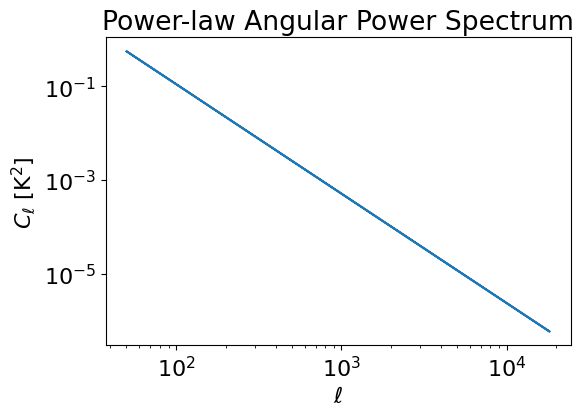

In [ ]:
# Plot the assumed power spectrum
plt.figure(figsize=(6,4))
plt.loglog(ell.flatten(),c_ell.flatten())
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$ [K$^2$]")
plt.title("Power-law Angular Power Spectrum")
plt.show()

# Simulate the sky based on the power spectrum

In [ ]:
def simulate_sky_field(cl, npix, seed = None):

    if seed is not None:
        np.random.seed(seed)

    # draw independent Gaussian random variates for real and imaginary parts
    # and then multiply by the sqrt(power) or sigma
    rand_complex = (np.random.normal(size=(npix, npix))
                    + 1j * np.random.normal(size=(npix, npix)))

    sigma = np.sqrt(cl)
    DeltaT_hat = sigma * rand_complex

    # Take an inverse FFT to get the sky field
    sky = np.fft.ifft2(np.fft.ifftshift(DeltaT_hat)).real

    return sky

In [ ]:
deltaT = simulate_sky_field(c_ell, npix = npix, seed = 102)

## Generate a theta grid in sky plane

In [ ]:
theta_x = (np.arange(npix) - npix / 2) * (np.rad2deg(pixel_size))
theta_y = theta_x
lx, my = np.meshgrid(theta_x, theta_x, indexing="xy")

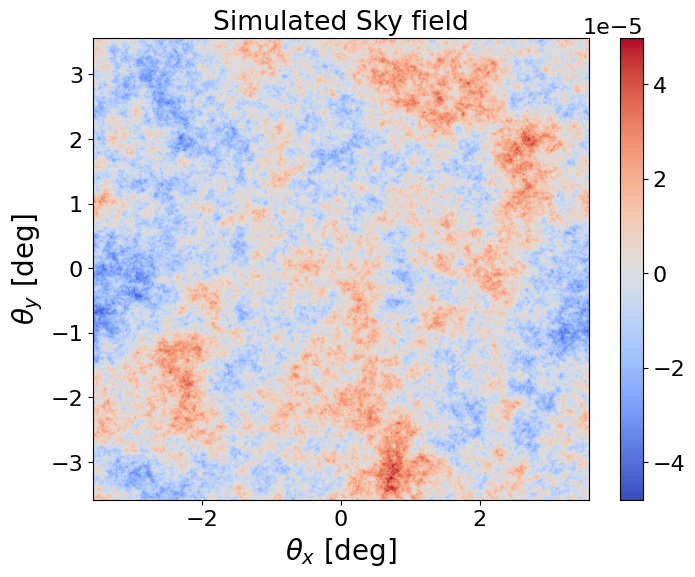

In [ ]:
# Plot the simulated ideal sky
plt.figure(figsize=(8,6),dpi=100)
ext = (theta_x[0], theta_x[-1], theta_y[0], theta_y[-1])
plt.imshow(deltaT, aspect='auto',origin='lower',cmap='coolwarm',extent=ext )
plt.colorbar()
plt.xlabel(r"$\theta_{x}$ [deg]",fontsize=20)
plt.ylabel(r"$\theta_{y}$ [deg]",fontsize=20)
plt.title("Simulated Sky field")
plt.show()

## Primary Beam Model

Interferometers do not observe the entire sky uniformly.  
Each antenna has a **primary beam response**, which acts as a directional sensitivity pattern.

The primary beam:

- Multiplies the true sky brightness  
- Suppresses emission toward the edges of the field of view  
- Reduces large-scale power in the measured signal  

---

### Beam–Sky Relationship

If the true sky is $ I(\theta_x, \theta_y) $,  
and the primary beam is $ A(\theta_x, \theta_y) $,  

then the observed sky becomes:

$
I_{\mathrm{obs}}(\theta_x, \theta_y)
=
A(\theta_x, \theta_y)\, I(\theta_x, \theta_y)
$

---

### Gaussian Beam Model

We model the primary beam as a circular Gaussian:

$
A(\theta)
=
\exp\left(
-\frac{\theta^2}{\theta_0^2}
\right)
$

where:

- $ \theta $ = angular distance from the pointing centre  
- $ \theta_0 = 0.6\,\theta_{\mathrm{FWHM}} $  
- $ \theta_{\mathrm{FWHM}} \approx 1.22 \frac{\lambda}{D} $

Here:

- $ \lambda $ = observing wavelength  
- $ D $ = effective station diameter  

---

### Beam Suppression of Power

Because the beam multiplies the sky in real space,  
it **convolves** the sky in Fourier space:

$
\tilde{I}_{\mathrm{obs}}(u,v)
=
\tilde{A}(u,v)
*
\tilde{I}(u,v)
$

This leads to suppression of the angular power spectrum.

To approximately correct for this effect, we divide by the mean squared beam:

$
\langle A^2 \rangle
=
\frac{1}{\Omega_{\mathrm{map}}}
\int A^2(\theta)\, d\Omega
$

where:

$
\Omega_{\mathrm{eff}}
=
\int A^2(\theta)\, d\Omega
$

is the **effective beam area**.

This normalization compensates for the power suppression introduced by the primary beam.

### Note: We will model the primary beam as a gaussian based on the GMRT PB model since SKA beam is similar to it. The SKA low beam can be obtained from ska_ost_array_config modules. Check out the [beam-formation notebooks](https://gitlab.com/ska-telescope/ost/ska-ost-array-config/-/blob/master/docs/examples/examples_beamforming.ipynb?ref_type=heads) given by SKAO team

In [ ]:
def primary_beam_ska(n_pix: int, dtheta: float,
                       theta_fwhm_rad: float):
    """Generate a primary beam model of the telescope.

    The primary beam of GMRT is well modelled by a circular Gaussian
    A(θ) = exp(-θ²/θ₀²), where θ₀ = 0.6 θ_FWHM.  The
    full width at half maximum of the GMRT 150 MHz beam is
    approximately 157 arcmin. See Eqn: 2,3,4 in arxiv:1409.7789
    We'll use the same model for SKA-Low as well, since it is also an aperture array with a similar primary beam shape.

    Parameters
    ----------
    n_pix : int
        size of the image.
    dtheta : float
        Pixel size in radians.
    theta_fwhm_rad : float, optional
        Full width at half maximum of the primary beam in
        rad.

    Returns
    -------
    beam: np.ndarray
        Beam in 2D space
    float
        Beam width parameter θ₀ in radians.
    """
    # see eqn 4 of arxiv:1409.7789 and discussion there for 0.6 parameter
    theta0 = 0.6 * theta_fwhm_rad  # beam width parameter

    # coordinate grid
    coords = (np.arange(n_pix) - n_pix // 2) * dtheta
    X, Y = np.meshgrid(coords, coords, indexing='ij')
    R2 = X ** 2 + Y ** 2
    beam = np.exp(-R2 / (theta0 ** 2))
    return  beam, theta0

def beam_normalization(beam: np.ndarray, fov_rad, npix) -> tuple[float, float]:
    """Return beam normalization factors for map and visibility estimators.

    Notes
    -----
    For a beam-weighted field ``I_b = A I`` with spatially slowly varying
    statistics, both map- and visibility-based power estimates are suppressed
    approximately by ``<A^2>``. This function returns:

    - ``a2_mean = <A^2>`` over the simulated FoV (dimensionless), and
    - ``omega_eff = ∫ A^2 dΩ`` in steradians.
    """
    dtheta = fov_rad / npix
    omega_pix = dtheta * dtheta
    omega_eff = float(np.sum(beam**2) * omega_pix)
    omega_map = fov_rad * fov_rad
    a2_mean = omega_eff / omega_map
    return a2_mean, omega_eff

In [ ]:
beam, theta0 = primary_beam_ska(npix, pixel_size, PB_fwhm)
a2_mean, omega_eff = beam_normalization(beam, fov_rad, npix)
print(f"Beam normalization factors: <A^2> = {a2_mean:.4f}, Omega_eff = {np.rad2deg(np.sqrt(omega_eff)):.2f} deg")

Beam normalization factors: <A^2> = 0.1411, Omega_eff = 2.69 deg


In [ ]:
# Apply the primary beam to the simulated skymap
deltaT_beam =  deltaT * beam

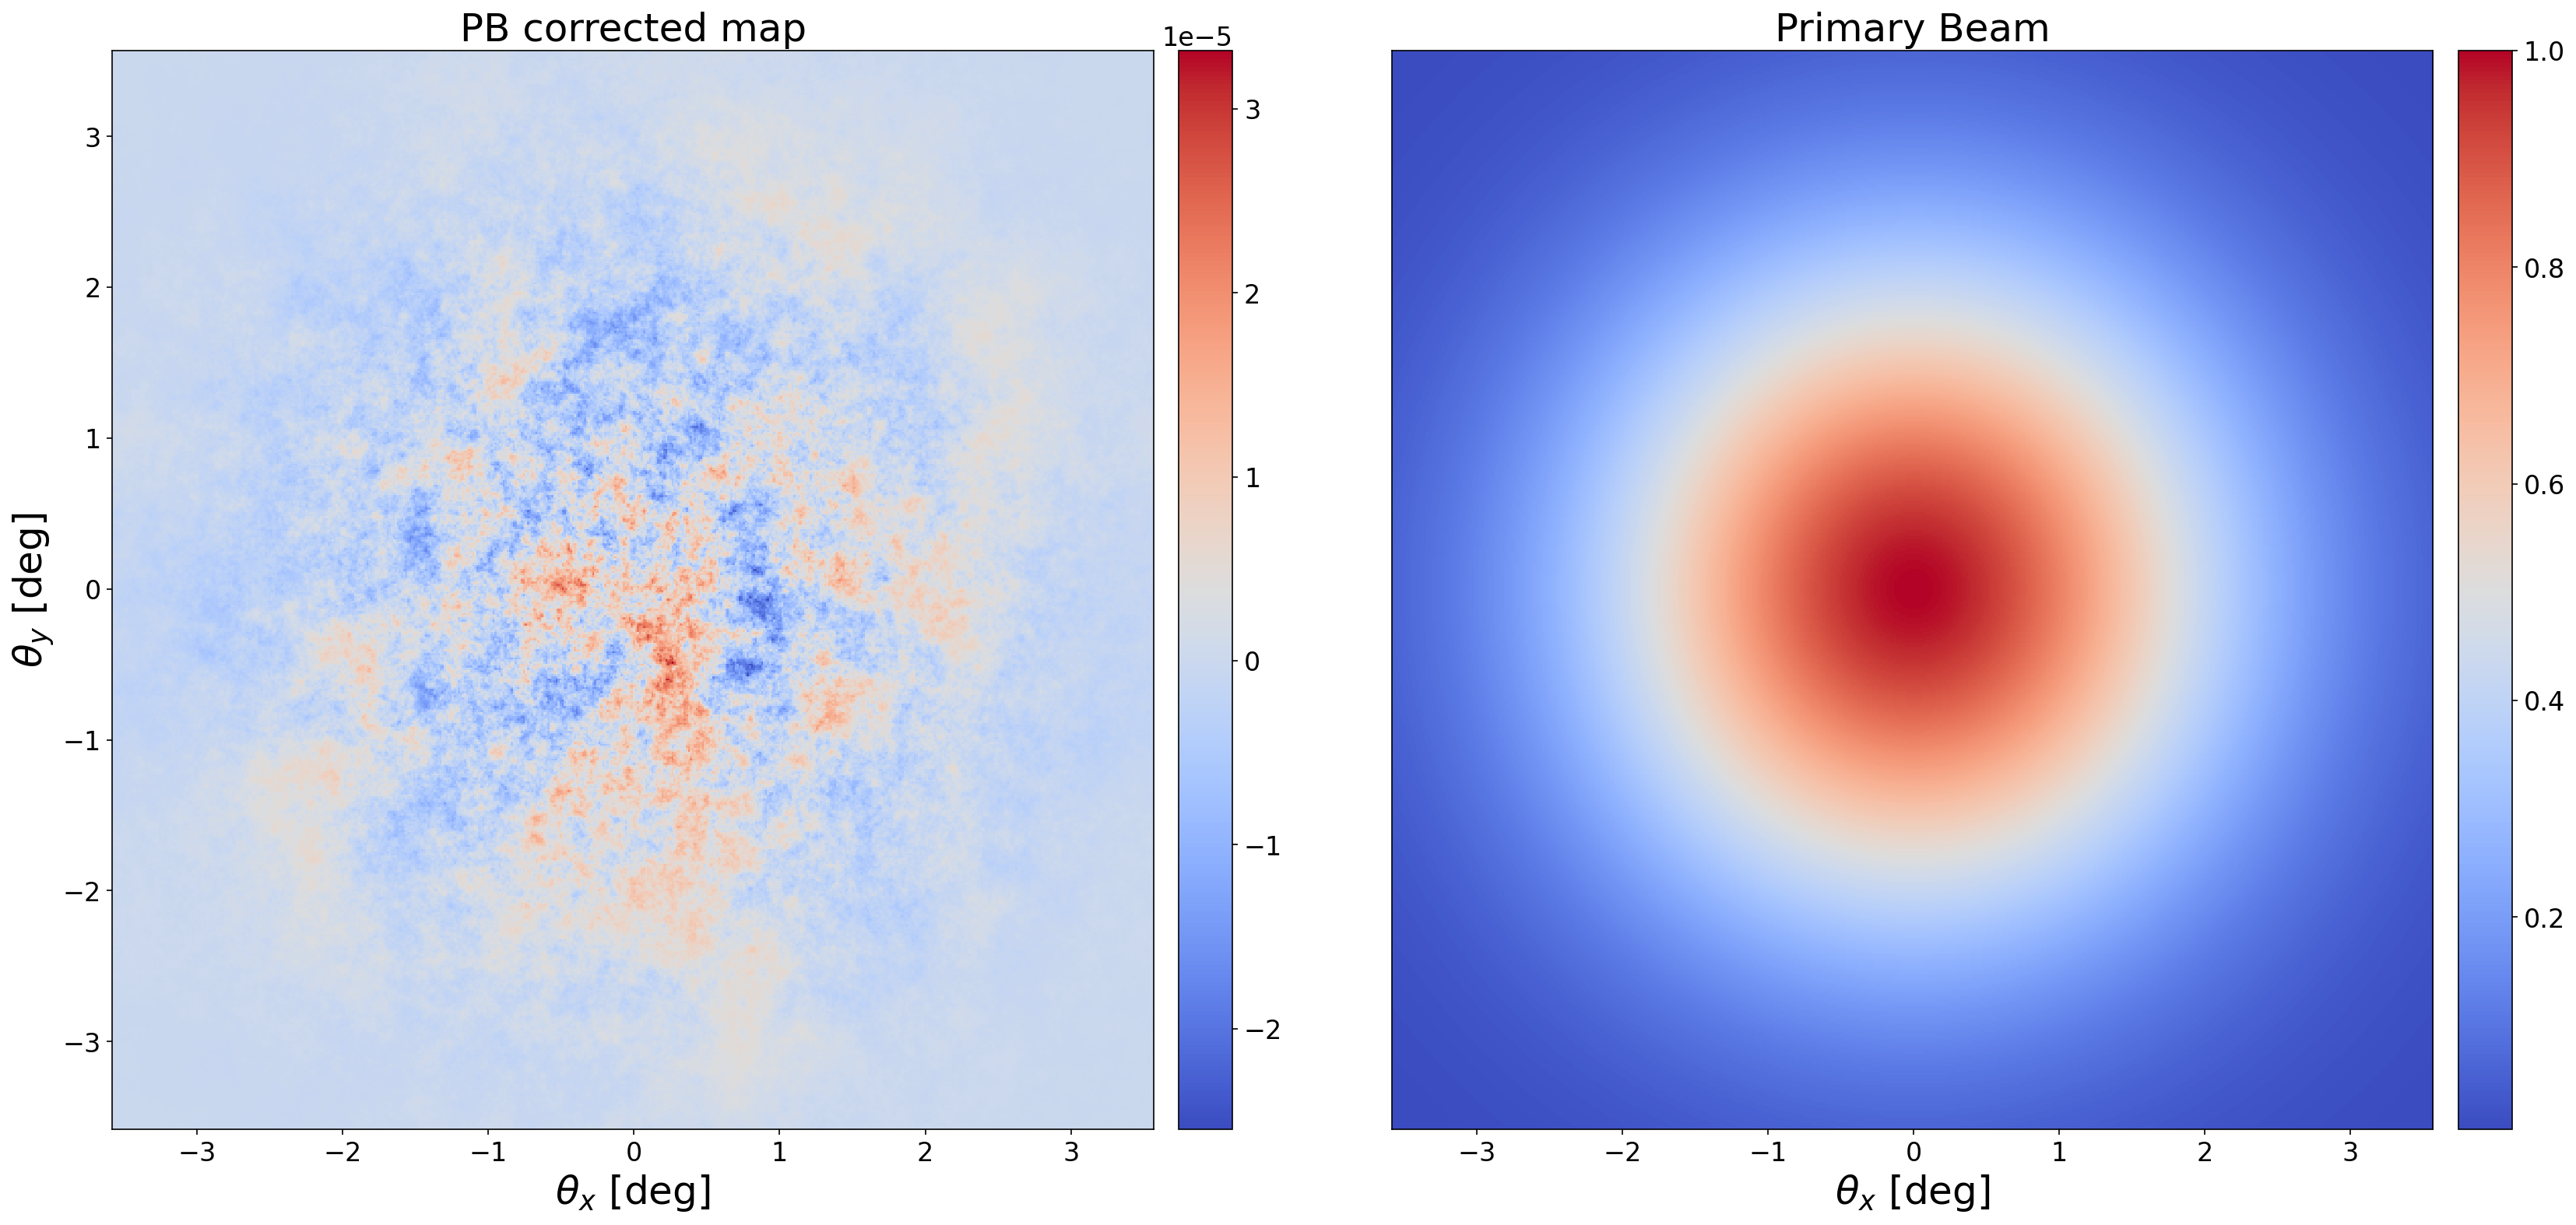

In [ ]:
ext = (theta_x[0], theta_x[-1], theta_y[0], theta_y[-1])
imshow_kwargs = dict(aspect='auto', origin='lower', interpolation='nearest',
                     extent=ext,cmap='coolwarm')


fig = plt.figure(num=1, figsize=(28, 12), dpi=150)

gspec = gridspec.GridSpec(1, 2, wspace=0.02)

plt.subplot(gspec[0, 0])
plt.imshow(deltaT_beam, **imshow_kwargs)
plt.xlabel(r"$\theta_{x}$ [deg]",fontsize=24)
plt.ylabel(r"$\theta_{y}$ [deg]",fontsize=24)
plt.title(f'PB corrected map',fontsize=24)
plt.colorbar(orientation='vertical',pad=0.02)


plt.subplot(gspec[0, 1])
plt.imshow(beam, **imshow_kwargs)
plt.xlabel(r"$\theta_{x}$ [deg]",fontsize=24)
plt.title(f'Primary Beam',fontsize=24)
plt.yticks([])
plt.colorbar(orientation='vertical',pad=0.02)
plt.show()

## Convert Sky to Visibilities

In radio interferometry, the fundamental observable is the **visibility**.

For a small field of view (flat-sky approximation), the visibility is given by:

$
V(u,v)
=
\int \int
I(l,m)\,
e^{-2\pi i (u l + v m)}
\, dl \, dm
$

where:

- $ I(l,m) $ = sky brightness distribution  
- $ (l,m) $ = direction cosines on the sky  
- $ (u,v) $ = baseline coordinates in units of wavelength  

---

### Interpretation

The visibility is simply the **2D Fourier transform** of the sky brightness:

$
V(u,v)
=
\mathcal{F}
\left[
I(l,m)
\right]
$

Thus:

- Each baseline measures **one Fourier mode** of the sky.
- The full set of baselines samples the Fourier plane (UV plane).

---

### Effect of the Primary Beam

If a primary beam $ A(l,m) $ is present, the observed sky becomes:

$
I_{\mathrm{obs}}(l,m)
=
A(l,m)\, I(l,m)
$

The corresponding visibility is:

$
V_{\mathrm{obs}}(u,v)
=
\mathcal{F}
\left[
A(l,m)\, I(l,m)
\right]
$

Since multiplication in real space corresponds to convolution in Fourier space:

$
V_{\mathrm{obs}}(u,v)
=
\tilde{A}(u,v)
*
\tilde{I}(u,v)
$

This means the primary beam modifies and smooths the measured Fourier modes.

---

### In This Notebook

We compute:

- Visibilities from the sky **without** primary beam  
- Visibilities from the sky **with** primary beam applied  

This allows us to directly see how the beam changes the sampled power.

In [ ]:
def simulate_visibilities(deltaI: np.ndarray):
    """Compute model visibilities by Fourier transforming the sky.

    Parameters
    ----------
    deltaI : np.ndarray
        Specific intensity skymap.

    Returns
    -------
    vis: np.ndarray
        Two–dimensional array of visibilities at the uv grid
        points.
    """
    # forward FFT and multiply by the pixel area
    V = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(deltaI)))
    return V

In [ ]:
# compute model visibilities on the uv grid
V_grid = simulate_visibilities(deltaT) # without beam applied
V_grid_beam = simulate_visibilities(deltaT_beam) # with beam applied

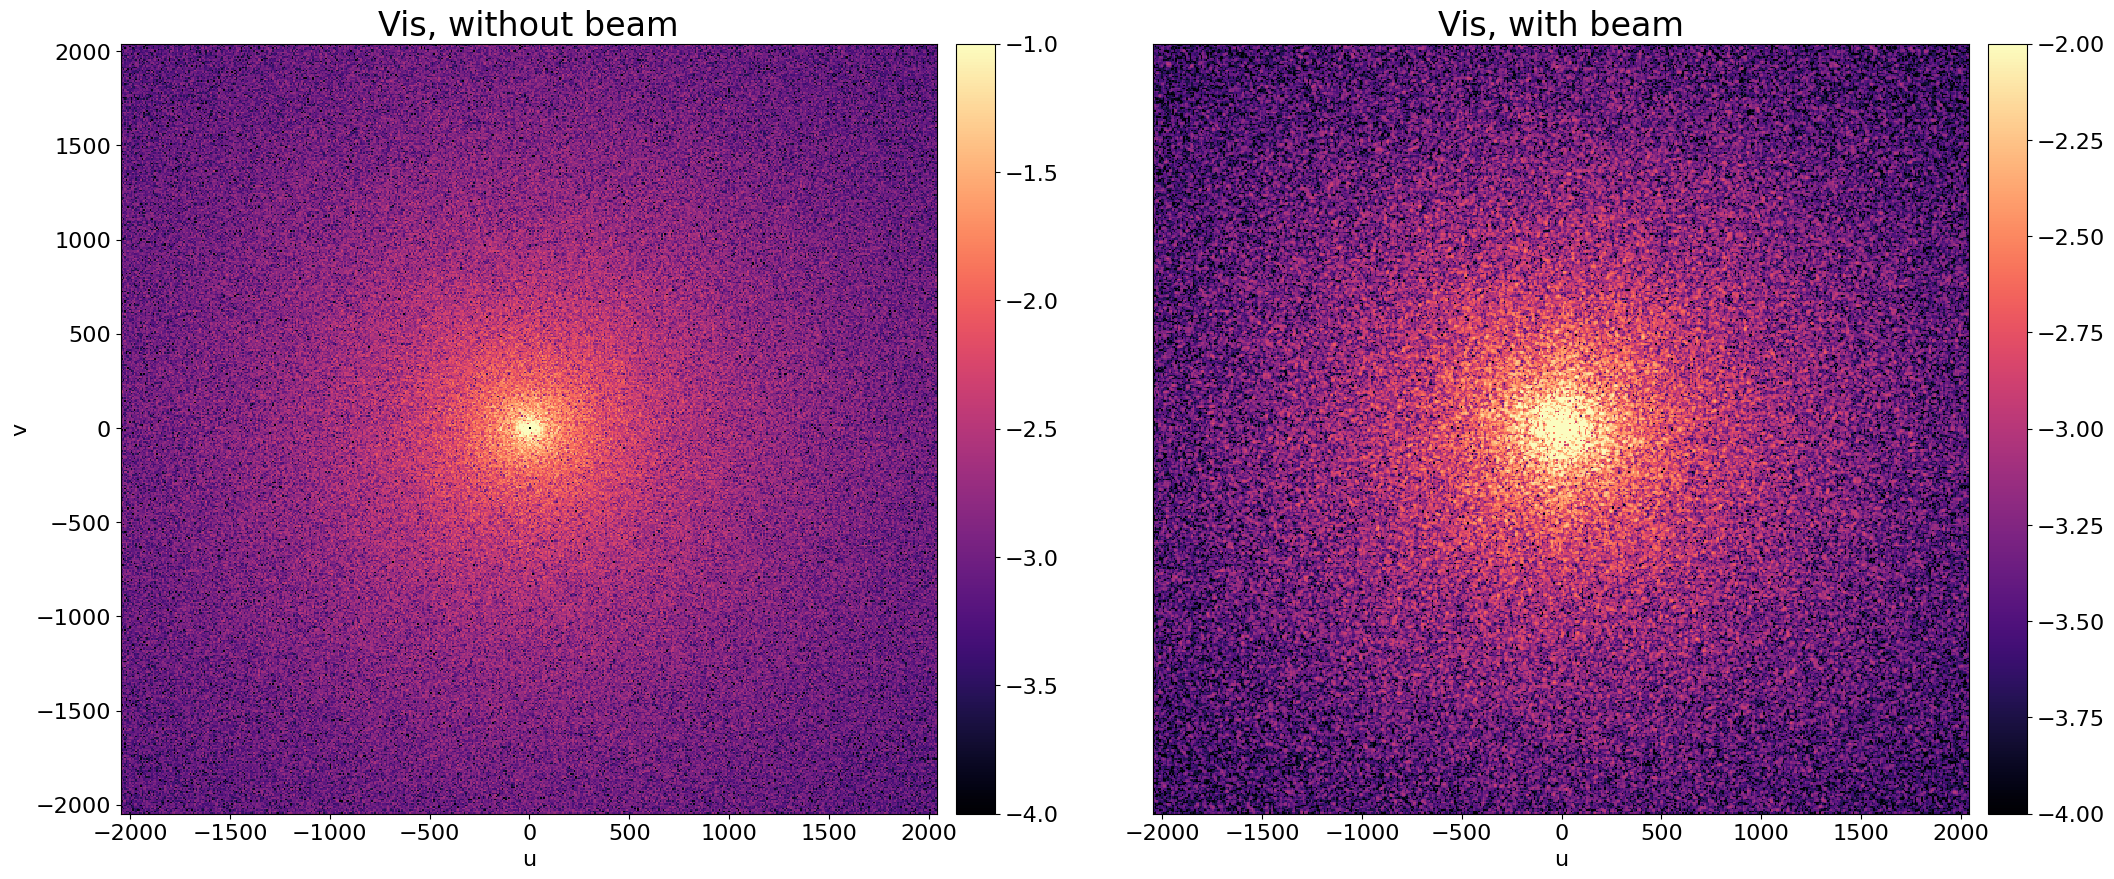

In [ ]:
ext = (u[0], u[-1], v[0], v[-1])
imshow_kwargs = dict(aspect='auto', origin='lower', interpolation='nearest',
                     extent=ext,cmap='magma')


fig = plt.figure(num=1, figsize=(26, 10), dpi=100)

gspec = gridspec.GridSpec(1, 2, wspace=0.05)

plt.subplot(gspec[0, 0])
plt.imshow(np.log10(abs(V_grid)),vmax=-1, vmin=-4, **imshow_kwargs)
plt.xlabel("u",fontsize=16)
plt.ylabel('v',fontsize=16)
plt.title(f'Vis, without beam',fontsize=24)
plt.colorbar(orientation='vertical',pad=0.02)


plt.subplot(gspec[0, 1])
plt.imshow(np.log10(abs(V_grid_beam)),vmax=-2, vmin=-4, **imshow_kwargs)
plt.xlabel("u",fontsize=16)
plt.title(f'Vis, with beam',fontsize=24)
plt.colorbar(orientation='vertical',pad=0.02)
plt.yticks([])
plt.show()

In [ ]:
# compute model visibilities on the uv grid
V_grid = simulate_visibilities(deltaT)
V_grid_with_beam = simulate_visibilities(deltaT_beam)

#### Optional Part: A little detour about units.

In [ ]:
# This is the function to convert the vis data to Jy unit.
# But I am not doing this.
# If you do it, then estimated power spec should be normalized by the square of this quantity
def temperature_to_intensity(deltaT: np.ndarray, freq_hz: float):
    """Convert brightness temperature (K) to specific intensity (Jy/sr).

    In the Rayleigh–Jeans limit the conversion factor is
    ∂B/∂T = 2 k_B / λ².  Intensities are expressed in Jy/sr by
    dividing by 10⁻²⁶.

    Parameters
    ----------
    deltaT : np.ndarray
        Brightness temperature fluctuations (K).
    freq_hz : float
        Observing frequency in Hz.

    Returns
    -------
    np.ndarray
        Specific intensity fluctuations (Jy/sr).
    float
        Conversion factor ∂B/∂T (Jy/sr per K).
    """
    lam = C_LIGHT / freq_hz
    dBdT = 2.0 * k_B / lam ** 2  # W m⁻² Hz⁻¹ sr⁻¹ per K
    dBdT_Jy = dBdT / 1e-26  # convert to Jy/sr per K
    return deltaT * dBdT_Jy, dBdT_Jy

In [ ]:
# convert to specific intensity
deltaI_beam_Jy, dBdT_Jy = temperature_to_intensity(deltaT_beam, freq_hz)
deltaI_Jy, dBdT_Jy = temperature_to_intensity(deltaT, freq_hz)

#### We will NOT be using deltaI_beam_Jy, dBdT_Jy, deltaI_Jy, dBdT_Jy

# Now given the simulated vis from a known power spec, sample the UV-tracks (computed before)

We now mimic a real interferometer:

We do NOT use the full Fourier grid.

We sample only at UV coordinates from the array.

This introduces sampling bias.
### Also, We are not adding noise here !!!!!!!!!!!!!!!!!!!!!!!!


In [ ]:
def sample_visibilities_from_grid(
    vis_grid: np.ndarray,
    u_track: np.ndarray,
    v_track: np.ndarray,
    seed = 102
) -> np.ndarray:
    """Sample a gridded visibility plane at uv-track coordinates."""
    rng = np.random.default_rng(seed + 1)
    du = 1.0 / (npix * pixel_size)

    # map uv to nearest grid index (FFT-shifted grid centered at zero)
    iu = np.rint(u_track / du + npix / 2).astype(int)
    iv = np.rint(v_track / du + npix / 2).astype(int)
    ok = (iu >= 0) & (iu < npix) & (iv >= 0) & (iv < npix)

    vis = np.full(u_track.size, np.nan + 1j * np.nan, dtype=np.complex128)
    vis[ok] = vis_grid[iv[ok], iu[ok]]

    #if cfg.noise_std_jy > 0:
    #    vis[ok] += cfg.noise_std_jy * (rng.normal(size=ok.sum()) + 1j * rng.normal(size=ok.sum()))
    return vis

In [ ]:
vis_track = sample_visibilities_from_grid(V_grid, U, V)
vis_track_with_beam = sample_visibilities_from_grid(V_grid_with_beam, U, V)

## Estimate Angular Power Spectrum

We now estimate the angular power spectrum $ C_\ell $ from three cases:

1. The full simulated sky map  
2. The beam-modified sky map  
3. The sampled visibilities along UV tracks  

We then compare the recovered spectra with the input theoretical model.

---

### Definition of the Angular Power Spectrum

For a statistically isotropic field in the flat-sky approximation:

$
C_\ell
=
\langle
|\tilde{I}(\mathbf{\ell})|^2
\rangle
$

where:

- $ \tilde{I}(\mathbf{\ell}) $ is the Fourier transform of the sky  
- $ \ell = 2\pi \sqrt{u^2 + v^2} $  
- The brackets $ \langle \cdot \rangle $ denote averaging over modes with the same $ \ell $

---

### Estimating $ C_\ell $ from a Map

From a sky map $ I(\theta_x, \theta_y) $:

1. Compute the Fourier transform:
   $
   \tilde{I}(u,v)
   =
   \mathcal{F}
   \left[
   I(\theta_x, \theta_y)
   \right]
   $

2. Compute the 2D power:
   $
   P(u,v)
   =
   |\tilde{I}(u,v)|^2
   $

3. Bin into annuli of constant \( \ell \) to obtain:
   $
   C_\ell
   =
   \langle P(u,v) \rangle_{\ell\text{-bin}}
   $

If a primary beam is applied, we correct approximately by dividing by:

$
\langle A^2 \rangle
$

to compensate for beam suppression.

---

### Estimating $ C_\ell $ from Visibilities

For sampled visibilities:

$
C_\ell
=
\langle |V(u,v)|^2 \rangle_{\ell\text{-bin}}
$

where only measured $ (u,v) $ points are used.

This introduces:

- Incomplete sampling
- Increased variance
- Possible bias at large scales (small $ \ell $)

---

### Binning Procedure

We divide the multipole range into logarithmic bins:

$
\ell_{\text{min}}
<
\ell
<
\ell_{\text{max}}
$

and compute:

$
C_\ell^{\text{bin}}
=
\frac{1}{N_{\text{modes}}}
\sum_{\ell_i \in \text{bin}}
|V_i|^2
$

The statistical uncertainty is estimated as:

$
\sigma_{C_\ell}
=
\frac{\mathrm{std}(|V|^2)}{\sqrt{N_{\text{modes}}}}
$

---

### Goal

By comparing:

- Input model $ C_\ell^{\text{input}} $
- Map-derived spectrum
- Visibility-derived spectrum

we can study how:

- Primary beam effects  
- UV sampling  
- Array configuration  

impact power spectrum recovery.

In [ ]:
def bin_cls(ell: np.ndarray, p2d: np.ndarray,ell_min: float, ell_max:float,
            n_ell_bins = 20, logspace = True):
    """Bin a 2D power field into 1D angular power spectrum bins."""

    if logspace:
        bins = np.logspace(np.log10(ell_min), np.log10(ell_max), n_ell_bins + 1)
    else:
        bins = np.linspace(ell_min, ell_max,n_ell_bins + 1)

    centers = np.sqrt(bins[:-1] * bins[1:])
    cl = np.full(n_ell_bins, np.nan)
    err = np.full(n_ell_bins, np.nan)
    for i in range(n_ell_bins):
        m = (ell >= bins[i]) & (ell < bins[i + 1]) & np.isfinite(p2d)
        if np.any(m):
            vals = p2d[m]
            cl[i] = vals.mean()
            err[i] = vals.std() / np.sqrt(vals.size)
    return centers, cl, err


def estimate_cls_from_map(sky: np.ndarray,ell_grid: np.ndarray,
                          ell_min: float, ell_max:float, n_ell_bins = 20, logspace=True,
                          beam_a2_mean: float = 1.0):
    """Estimate binned ``C_ell`` from a map."""

    fk = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(sky)))
    pk = np.abs(fk) ** 2 / beam_a2_mean
    return bin_cls(ell_grid.ravel(), pk.ravel(),ell_min, ell_max, n_ell_bins,logspace)


def estimate_cls_from_visibilities(vis: np.ndarray, u_track: np.ndarray, v_track: np.ndarray,
                                   ell_min: float, ell_max:float, n_ell_bins=20, logspace=True,
                                  beam_a2_mean: float = 1.0):
    """"Estimate binned ``C_ell`` from sampled visibilities."""

    m = np.isfinite(vis.real)
    ell = 2.0 * np.pi * np.sqrt(u_track[m] ** 2 + v_track[m] ** 2)
    pk = np.abs(vis[m]) ** 2 / beam_a2_mean
    #if cfg.noise_std_jy > 0:
    #    p = np.maximum(p - 2.0 * cfg.noise_std_jy**2, 0.0)
    return bin_cls(ell, pk, ell_min, ell_max, n_ell_bins,logspace)

In [ ]:
# PS for a map without PB correction
lmin_map = 2 * ell[ell>0.0].ravel().min()
lmax_map = np.pi / pixel_size
ll, cl_map, cl_map_err = estimate_cls_from_map(deltaT, ell,lmin_map, lmax_map,n_ell_bins=20,
                                               logspace=True, beam_a2_mean=1.0 )

# PS for a map with PB applied
ll, cl_map_beam, cl_map_beam_err = estimate_cls_from_map(deltaT_beam, ell,lmin_map,
                                                         lmax_map,n_ell_bins=20,
                                                         logspace=True, beam_a2_mean = a2_mean )

In [ ]:
# Input power spec model
c_input = powerlaw_cls(ll, amp = Amp, ell0 = 1000.0, beta = beta)

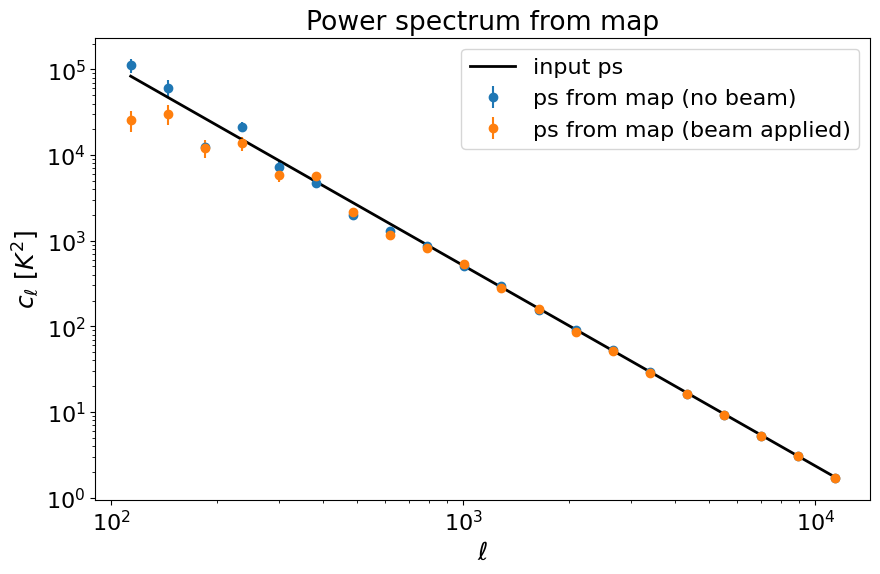

In [ ]:
plt.figure(figsize=(10,6))
plt.errorbar(ll,cl_map*1e6,cl_map_err*1e6,
             marker='o', linestyle='None', label='ps from map (no beam)')
plt.errorbar(ll,cl_map_beam*1e6,cl_map_beam_err*1e6,marker='o', linestyle='None', label='ps from map (beam applied)')
plt.plot(ll,c_input*1e6,color='black', lw=2,label='input ps')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$',fontsize=18)
plt.ylabel(r'$c_{\ell}$ [$K^{2}$]',fontsize=18)

plt.legend()
plt.title("Power spectrum from map")
plt.show()

## Compute PS from simulated Vis track

In [ ]:
lbin, cl_vis, cl_vis_err = estimate_cls_from_visibilities(vis = vis_track,
                                   u_track= U, v_track = V,
                                   ell_min = lmin_map, ell_max = lmax_map,
                                    n_ell_bins=20, logspace=True,beam_a2_mean= 1.0)


lbin, cl_vis_beam, cl_vis_beam_err = estimate_cls_from_visibilities(vis = vis_track_with_beam,
                                   u_track= U, v_track = V,
                                   ell_min = lmin_map, ell_max = lmax_map,
                                    n_ell_bins=20, logspace=True, beam_a2_mean= a2_mean)

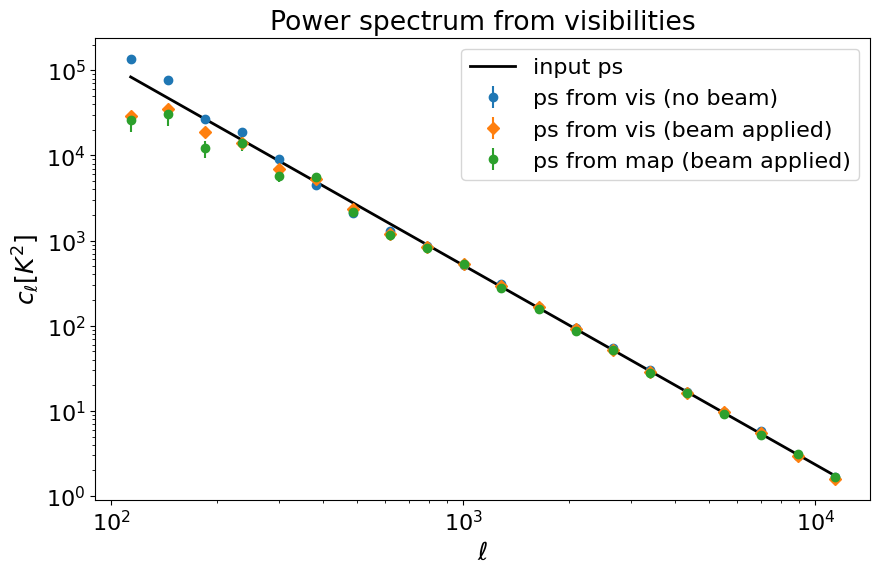

In [ ]:
plt.figure(figsize=(10,6))
plt.errorbar(lbin,cl_vis*1e6,cl_vis_err*1e6,marker='o', linestyle='None', label='ps from vis (no beam)')
plt.errorbar(lbin,cl_vis_beam*1e6,cl_vis_beam_err*1e6,marker='D', linestyle='None', label='ps from vis (beam applied)')
plt.errorbar(ll,cl_map_beam*1e6,cl_map_beam_err*1e6,marker='o', linestyle='None', label='ps from map (beam applied)')
plt.plot(ll,c_input*1e6,color='black', lw=2,label='input ps')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$ ',fontsize=18)
plt.ylabel(r'$c_{\ell}$[$K^{2}$]',fontsize=18)
plt.legend()
plt.title("Power spectrum from visibilities")
plt.show()

# EXERCISE: Change observation setup
e.g. RA, DEC, Observation duration, etc.

Remember to take into account the actual "visibility" of your setup before proceeding or you might end up with some nonsense sampling.

Check out cell 32 in [this notebook](https://gitlab.com/ska-telescope/ost/ska-ost-array-config/-/blob/master/docs/examples/examples.ipynb) [especially the functions ska_ost_array_config.simulation_utils.find_rise_set_times() and ska_ost_array_config.simulation_utils.simulate_observation()]

In [ ]:
# Test block for SKA Local time to ISOT if ska_ost_array_config can't be installed to verify visibility.
# You can use any star atlas (e.g. Stellarium) to figure out local rise and set times of certain points.

from astropy.time import Time
from astropy import units as u

# Define the local time and timezone
ska_local_time = '2026-03-01T13:35:00.0'
ska_local_timezone = 'Australia/Perth'

# Create Time object (ensure correct scale and format)
t_local = Time(ska_local_time, format='isot', scale='utc')

# Perth is UTC+8, adjust the time manually by subtracting 8 hours
t_utc = t_local - 8 * u.hour

print("UTC time:", t_utc.isot)

# Print UTC time 4 hours before and after
h_hours = 4
print(f"UTC time {h_hours} hours before:", (t_utc - h_hours * u.hour).isot)
print(f"UTC time {h_hours} hours after:", (t_utc + h_hours * u.hour).isot)

UTC time: 2026-03-01T05:35:00.000
UTC time 4 hours before: 2026-03-01T01:35:00.000
UTC time 4 hours after: 2026-03-01T09:35:00.000


# EXERCISE: Modify Array Layout
Try flagging out the arm antennas or the central square antennas (Hint: the station name codes in the layout file stand for Central, East-arm, North-arm and South-arm) and see the effect on recovered power spectra

# Exercise: Try with GMRT array instead

Note: You might need to write a modified function to read array layout file provided.

In [ ]:
# GMRT geodetic coordinates (latitude, longitude and height)
lat_GMRT = 19.0931 * DEG2RAD
lon_GMRT = 74.0506 * DEG2RAD
alt_GMRT = 588.0